In [1]:
import pandas as pd

df = pd.read_csv('customer_support_tickets.csv')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)


Shape: (8469, 17)

Columns:
 ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']

First 3 rows:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


In [2]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== COLUMN DATA TYPES ===")
print(df.dtypes)

print("\n=== TICKET PRIORITY (our main target) ===")
print(df['Ticket Priority'].value_counts())

print("\n=== TICKET STATUS ===")
print(df['Ticket Status'].value_counts())

print("\n=== TICKET TYPE ===")
print(df['Ticket Type'].value_counts())

=== MISSING VALUES ===
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

=== COLUMN DATA TYPES ===
Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                 

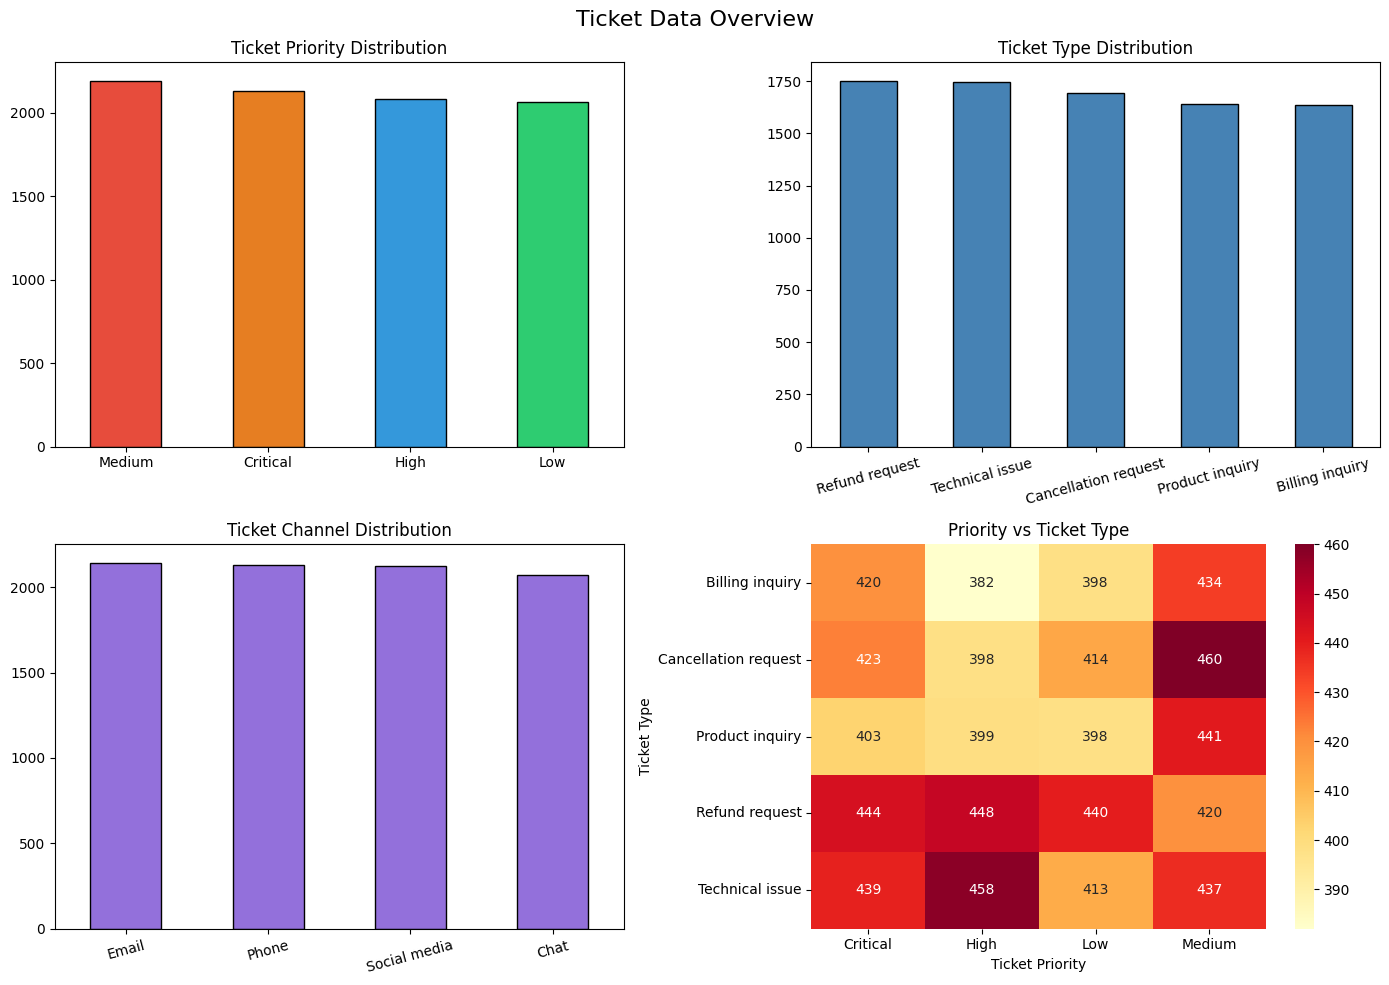

Chart saved!


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ticket Data Overview', fontsize=16)

# Priority distribution
df['Ticket Priority'].value_counts().plot(kind='bar', ax=axes[0,0], 
    color=['#e74c3c','#e67e22','#3498db','#2ecc71'], edgecolor='black')
axes[0,0].set_title('Ticket Priority Distribution')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=0)

# Ticket type distribution
df['Ticket Type'].value_counts().plot(kind='bar', ax=axes[0,1],
    color='steelblue', edgecolor='black')
axes[0,1].set_title('Ticket Type Distribution')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=15)

# Ticket channel
df['Ticket Channel'].value_counts().plot(kind='bar', ax=axes[1,0],
    color='mediumpurple', edgecolor='black')
axes[1,0].set_title('Ticket Channel Distribution')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=15)

# Priority vs Ticket Type heatmap
pivot = pd.crosstab(df['Ticket Type'], df['Ticket Priority'])
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1,1])
axes[1,1].set_title('Priority vs Ticket Type')

plt.tight_layout()
plt.savefig('ticket_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [4]:
# Look at sample descriptions per priority
for priority in ['Critical', 'High', 'Medium', 'Low']:
    print(f"\n{'='*50}")
    print(f"PRIORITY: {priority}")
    print('='*50)
    samples = df[df['Ticket Priority'] == priority]['Ticket Description'].dropna().head(3)
    for i, text in enumerate(samples, 1):
        print(f"\nSample {i}: {text[:200]}")


PRIORITY: Critical

Sample 1: I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I'

Sample 2: I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing 

Sample 3: I'm unable to access my {product_purchased} account. It keeps displaying an 'Invalid Credentials' error, even though I'm using the correct login information. How can I regain access to my account?

So

PRIORITY: High

Sample 1: I'm having an issue with the {product_purchased}. Please assist. 1-800-799-0808.

Product Search: What's New in 2-3-4-5? Report Feedback Customer Service is your best I'm using the original charger th

Sample 2: I'm having an issue with the {product_purchased}. Please assist.

4. It is possible that we cannot find s

In [5]:
df2 = pd.read_csv('customer_support_tickets_200k.csv')

print("Shape:", df2.shape)
print("\nColumns:\n", df2.columns.tolist())
print("\nPriority values:\n", df2['priority'].value_counts())
print("\n=== SAMPLE DESCRIPTIONS PER PRIORITY ===")
for priority in df2['priority'].unique():
    print(f"\n--- {priority} ---")
    samples = df2[df2['priority'] == priority]['issue_description'].dropna().head(2)
    for text in samples:
        print(f"• {text[:150]}")

Shape: (200000, 30)

Columns:
 ['ticket_id', 'customer_name', 'customer_email', 'product', 'category', 'issue_description', 'resolution_notes', 'priority', 'status', 'channel', 'region', 'customer_age', 'customer_gender', 'subscription_type', 'customer_tenure_months', 'previous_tickets', 'customer_satisfaction_score', 'first_response_time_hours', 'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date', 'escalated', 'sla_breached', 'operating_system', 'browser', 'payment_method', 'language', 'preferred_contact_time', 'issue_complexity_score', 'customer_segment']

Priority values:
 priority
High      50241
Urgent    50143
Medium    49854
Low       49762
Name: count, dtype: int64

=== SAMPLE DESCRIPTIONS PER PRIORITY ===

--- Urgent ---
• The payment was deducted from my bank account but the transaction shows failed.
• I found a bug in the latest update affecting report generation.

--- Medium ---
• The application crashes whenever I try to upload a file.
• My subscription 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Quick data quality check
print("=== MISSING VALUES ===")
print(df2.isnull().sum()[df2.isnull().sum() > 0])

print("\n=== SLA BREACHED ===")
print(df2['sla_breached'].value_counts())

print("\n=== ESCALATED ===")
print(df2['escalated'].value_counts())

print("\n=== PRIORITY vs SLA BREACHED ===")
print(pd.crosstab(df2['priority'], df2['sla_breached'], normalize='index').round(2))

=== MISSING VALUES ===
browser    40023
dtype: int64

=== SLA BREACHED ===
sla_breached
Yes    100043
No      99957
Name: count, dtype: int64

=== ESCALATED ===
escalated
Yes    100421
No      99579
Name: count, dtype: int64

=== PRIORITY vs SLA BREACHED ===
sla_breached   No  Yes
priority              
High          0.5  0.5
Low           0.5  0.5
Medium        0.5  0.5
Urgent        0.5  0.5


In [7]:
print("=== RESOLUTION TIME ===")
print(df2['resolution_time_hours'].describe())

print("\n=== FIRST RESPONSE TIME ===")
print(df2['first_response_time_hours'].describe())

print("\n=== ISSUE COMPLEXITY SCORE ===")
print(df2['issue_complexity_score'].describe())

print("\n=== RESOLUTION TIME BY PRIORITY ===")
print(df2.groupby('priority')['resolution_time_hours'].mean().round(2))

=== RESOLUTION TIME ===
count    200000.000000
mean        120.539718
std          68.969143
min           1.000000
25%          60.810000
50%         120.450000
75%         180.260000
max         240.000000
Name: resolution_time_hours, dtype: float64

=== FIRST RESPONSE TIME ===
count    200000.000000
mean         36.309180
std          20.654575
min           0.500000
25%          18.460000
50%          36.310000
75%          54.220000
max          72.000000
Name: first_response_time_hours, dtype: float64

=== ISSUE COMPLEXITY SCORE ===
count    200000.000000
mean          5.501365
std           2.875587
min           1.000000
25%           3.000000
50%           6.000000
75%           8.000000
max          10.000000
Name: issue_complexity_score, dtype: float64

=== RESOLUTION TIME BY PRIORITY ===
priority
High      120.28
Low       121.03
Medium    120.15
Urgent    120.71
Name: resolution_time_hours, dtype: float64


In [8]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 10000

# --- Define SLA thresholds by priority (industry standard) ---
sla_response = {'Low': 24, 'Medium': 12, 'High': 4, 'Urgent': 1}
sla_resolution = {'Low': 120, 'Medium': 48, 'High': 24, 'Urgent': 8}

priorities = np.random.choice(['Low', 'Medium', 'High', 'Urgent'], n,
                               p=[0.25, 0.30, 0.25, 0.20])

categories = np.random.choice(
    ['Login Issue', 'Payment Problem', 'Performance Issue',
     'Feature Request', 'Account Suspension', 'Subscription Cancellation',
     'Data Loss', 'Security Breach', 'Integration Failure', 'Billing Dispute'],
    n)

channels = np.random.choice(['Email', 'Chat', 'Phone', 'Portal'], n,
                              p=[0.35, 0.30, 0.20, 0.15])

complexity = np.where(priorities == 'Urgent',
                np.random.randint(6, 11, n),
             np.where(priorities == 'High',
                np.random.randint(4, 9, n),
             np.where(priorities == 'Medium',
                np.random.randint(2, 7, n),
                np.random.randint(1, 5, n))))

# --- Response and resolution times with realistic noise ---
response_time = np.array([
    np.random.exponential(sla_response[p] * 0.9)
    for p in priorities])

resolution_time = np.array([
    np.random.exponential(sla_resolution[p] * 0.95)
    for p in priorities])

previous_tickets = np.random.poisson(2.5, n)
customer_tenure = np.random.randint(1, 72, n)
customer_age = np.random.randint(18, 70, n)

# --- Engineer SLA breach from real business logic ---
sla_breach = np.array([
    1 if (response_time[i] > sla_response[priorities[i]] or
          resolution_time[i] > sla_resolution[priorities[i]])
    else 0
    for i in range(n)])

# --- Engineer escalation from complexity + breach ---
escalated = np.array([
    1 if (complexity[i] >= 7 and sla_breach[i] == 1) or
         (priorities[i] == 'Urgent' and response_time[i] > sla_response['Urgent'] * 1.5)
    else 0
    for i in range(n)])

df = pd.DataFrame({
    'priority': priorities,
    'category': categories,
    'channel': channels,
    'complexity_score': complexity,
    'response_time_hours': response_time.round(2),
    'resolution_time_hours': resolution_time.round(2),
    'previous_tickets': previous_tickets,
    'customer_tenure_months': customer_tenure,
    'customer_age': customer_age,
    'sla_breach': sla_breach,
    'escalated': escalated
})

print("Shape:", df.shape)
print("\nSLA Breach rate by priority:")
print(df.groupby('priority')['sla_breach'].mean().round(3))
print("\nEscalation rate by priority:")
print(df.groupby('priority')['escalated'].mean().round(3))
print("\nSample:")
print(df.head(3))

Shape: (10000, 11)

SLA Breach rate by priority:
priority
High      0.556
Low       0.570
Medium    0.574
Urgent    0.566
Name: sla_breach, dtype: float64

Escalation rate by priority:
priority
High      0.227
Low       0.000
Medium    0.000
Urgent    0.492
Name: escalated, dtype: float64

Sample:
  priority         category channel  complexity_score  response_time_hours  \
0   Medium        Data Loss    Chat                 6                 0.51   
1   Urgent  Feature Request    Chat                 9                 0.63   
2     High  Payment Problem    Chat                 4                 4.66   

   resolution_time_hours  previous_tickets  customer_tenure_months  \
0                  32.29                 0                      30   
1                   1.18                 4                      36   
2                  21.51                 3                      42   

   customer_age  sla_breach  escalated  
0            58           0          0  
1            37          

In [9]:
np.random.seed(42)
n = 10000

sla_response   = {'Low': 24, 'Medium': 12, 'High': 4,  'Urgent': 1}
sla_resolution = {'Low': 120,'Medium': 48, 'High': 24, 'Urgent': 8}

# Urgent tickets get handled faster — scale matters
response_scale   = {'Low': 28, 'Medium': 14, 'High': 5,  'Urgent': 0.8}
resolution_scale = {'Low': 130,'Medium': 52, 'High': 26, 'Urgent': 6}

priorities = np.random.choice(
    ['Low','Medium','High','Urgent'], n, p=[0.25,0.30,0.25,0.20])

categories = np.random.choice(
    ['Login Issue','Payment Problem','Performance Issue',
     'Feature Request','Account Suspension','Subscription Cancellation',
     'Data Loss','Security Breach','Integration Failure','Billing Dispute'], n)

channels = np.random.choice(
    ['Email','Chat','Phone','Portal'], n, p=[0.35,0.30,0.20,0.15])

complexity = np.where(priorities == 'Urgent', np.random.randint(6,11,n),
             np.where(priorities == 'High',   np.random.randint(4, 9,n),
             np.where(priorities == 'Medium', np.random.randint(2, 7,n),
                                              np.random.randint(1, 5,n))))

response_time   = np.array([np.random.exponential(response_scale[p])   for p in priorities])
resolution_time = np.array([np.random.exponential(resolution_scale[p]) for p in priorities])
previous_tickets  = np.random.poisson(2.5, n)
customer_tenure   = np.random.randint(1, 72, n)
customer_age      = np.random.randint(18, 70, n)

sla_breach = np.array([
    1 if (response_time[i]   > sla_response[priorities[i]] or
          resolution_time[i] > sla_resolution[priorities[i]])
    else 0
    for i in range(n)])

escalated = np.array([
    1 if (complexity[i] >= 7 and sla_breach[i] == 1) or
         (priorities[i] == 'Urgent' and response_time[i] > sla_response['Urgent'] * 1.5)
    else 0
    for i in range(n)])

df = pd.DataFrame({
    'priority':               priorities,
    'category':               categories,
    'channel':                channels,
    'complexity_score':       complexity,
    'response_time_hours':    response_time.round(2),
    'resolution_time_hours':  resolution_time.round(2),
    'previous_tickets':       previous_tickets,
    'customer_tenure_months': customer_tenure,
    'customer_age':           customer_age,
    'sla_breach':             sla_breach,
    'escalated':              escalated
})

print("SLA Breach rate by priority:")
print(df.groupby('priority')['sla_breach'].mean().round(3))

print("\nMean response time by priority:")
print(df.groupby('priority')['response_time_hours'].mean().round(2))

print("\nMean resolution time by priority:")
print(df.groupby('priority')['resolution_time_hours'].mean().round(2))

print("\nEscalation rate by priority:")
print(df.groupby('priority')['escalated'].mean().round(3))

# Save it
df.to_csv('tickets_clean.csv', index=False)
print("\nSaved as tickets_clean.csv")

SLA Breach rate by priority:
priority
High      0.663
Low       0.656
Medium    0.662
Urgent    0.485
Name: sla_breach, dtype: float64

Mean response time by priority:
priority
High       5.02
Low       28.82
Medium    14.57
Urgent     0.79
Name: response_time_hours, dtype: float64

Mean resolution time by priority:
priority
High       25.37
Low       131.81
Medium     51.74
Urgent      6.02
Name: resolution_time_hours, dtype: float64

Escalation rate by priority:
priority
High      0.27
Low       0.00
Medium    0.00
Urgent    0.42
Name: escalated, dtype: float64

Saved as tickets_clean.csv


In [10]:
np.random.seed(42)
n = 10000

sla_response   = {'Low': 24,  'Medium': 12, 'High': 4,  'Urgent': 1}
sla_resolution = {'Low': 120, 'Medium': 48, 'High': 24, 'Urgent': 8}

# Target breach rates: Urgent=20%, High=40%, Medium=60%, Low=75%
breach_prob = {'Urgent': 0.20, 'High': 0.40, 'Medium': 0.60, 'Low': 0.75}

priorities = np.random.choice(
    ['Low','Medium','High','Urgent'], n, p=[0.25,0.30,0.25,0.20])

categories = np.random.choice(
    ['Login Issue','Payment Problem','Performance Issue',
     'Feature Request','Account Suspension','Subscription Cancellation',
     'Data Loss','Security Breach','Integration Failure','Billing Dispute'], n)

channels = np.random.choice(
    ['Email','Chat','Phone','Portal'], n, p=[0.35,0.30,0.20,0.15])

complexity = np.where(priorities == 'Urgent', np.random.randint(6,11,n),
             np.where(priorities == 'High',   np.random.randint(4, 9,n),
             np.where(priorities == 'Medium', np.random.randint(2, 7,n),
                                              np.random.randint(1, 5,n))))

# Breach assigned directly by priority probability
sla_breach = np.array([
    np.random.binomial(1, breach_prob[p]) for p in priorities])

# Response time: if breached, exceed SLA; if not, stay under
response_time = np.array([
    np.random.uniform(sla_response[p] * 1.1, sla_response[p] * 3.0) if sla_breach[i]
    else np.random.uniform(sla_response[p] * 0.2, sla_response[p] * 0.95)
    for i, p in enumerate(priorities)])

resolution_time = np.array([
    np.random.uniform(sla_resol
                      

SyntaxError: incomplete input (4076298728.py, line 38)

In [11]:
np.random.seed(42)
n = 10000

sla_response   = {'Low': 24,  'Medium': 12, 'High': 4,  'Urgent': 1}
sla_resolution = {'Low': 120, 'Medium': 48, 'High': 24, 'Urgent': 8}

# Target breach rates: Urgent=20%, High=40%, Medium=60%, Low=75%
breach_prob = {'Urgent': 0.20, 'High': 0.40, 'Medium': 0.60, 'Low': 0.75}

priorities = np.random.choice(
    ['Low','Medium','High','Urgent'], n, p=[0.25,0.30,0.25,0.20])

categories = np.random.choice(
    ['Login Issue','Payment Problem','Performance Issue',
     'Feature Request','Account Suspension','Subscription Cancellation',
     'Data Loss','Security Breach','Integration Failure','Billing Dispute'], n)

channels = np.random.choice(
    ['Email','Chat','Phone','Portal'], n, p=[0.35,0.30,0.20,0.15])

complexity = np.where(priorities == 'Urgent', np.random.randint(6,11,n),
             np.where(priorities == 'High',   np.random.randint(4, 9,n),
             np.where(priorities == 'Medium', np.random.randint(2, 7,n),
                                              np.random.randint(1, 5,n))))

# Breach assigned directly by priority probability
sla_breach = np.array([
    np.random.binomial(1, breach_prob[p]) for p in priorities])

# Response time: if breached, exceed SLA; if not, stay under
response_time = np.array([
    np.random.uniform(sla_response[p] * 1.1, sla_response[p] * 3.0) if sla_breach[i]
    else np.random.uniform(sla_response[p] * 0.2, sla_response[p] * 0.95)
    for i, p in enumerate(priorities)])

resolution_time = np.array([
    np.random.uniform(sla_resolution[p] * 1.1, sla_resolution[p] * 2.5) if sla_breach[i]
    else np.random.uniform(sla_resolution[p] * 0.3, sla_resolution[p] * 0.95)
    for i, p in enumerate(priorities)])

previous_tickets  = np.random.poisson(2.5, n)
customer_tenure   = np.random.randint(1, 72, n)
customer_age      = np.random.randint(18, 70, n)

# Escalation: high complexity + breach, or Urgent breach
escalated = np.array([
    1 if (complexity[i] >= 7 and sla_breach[i] == 1) or
         (priorities[i] == 'Urgent' and sla_breach[i] == 1)
    else 0
    for i in range(n)])

df = pd.DataFrame({
    'priority':               priorities,
    'category':               categories,
    'channel':                channels,
    'complexity_score':       complexity,
    'response_time_hours':    response_time.round(2),
    'resolution_time_hours':  resolution_time.round(2),
    'previous_tickets':       previous_tickets,
    'customer_tenure_months': customer_tenure,
    'customer_age':           customer_age,
    'sla_breach':             sla_breach,
    'escalated':              escalated
})

print("SLA Breach rate by priority:")
print(df.groupby('priority')['sla_breach'].mean().round(3))

print("\nMean response time by priority:")
print(df.groupby('priority')['response_time_hours'].mean().round(2))

print("\nMean resolution time by priority:")
print(df.groupby('priority')['resolution_time_hours'].mean().round(2))

print("\nEscalation rate by priority:")
print(df.groupby('priority')['escalated'].mean().round(3))

print("\nOverall breach rate:", df['sla_breach'].mean().round(3))

df.to_csv('tickets_clean.csv', index=False)
print("Saved as tickets_clean.csv ✓")

SLA Breach rate by priority:
priority
High      0.404
Low       0.736
Medium    0.582
Urgent    0.201
Name: sla_breach, dtype: float64

Mean response time by priority:
priority
High       4.63
Low       40.04
Medium    17.06
Urgent     0.87
Name: response_time_hours, dtype: float64

Mean resolution time by priority:
priority
High       26.52
Low       177.97
Medium     63.19
Urgent      6.88
Name: resolution_time_hours, dtype: float64

Escalation rate by priority:
priority
High      0.169
Low       0.000
Medium    0.000
Urgent    0.201
Name: escalated, dtype: float64

Overall breach rate: 0.503
Saved as tickets_clean.csv ✓


Priority classes: ['High', 'Low', 'Medium', 'Urgent']

Training samples: 8000
Testing samples:  2000

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        High       0.84      0.91      0.88       487
         Low       0.98      0.90      0.94       509
      Medium       0.88      0.93      0.90       612
      Urgent       0.98      0.90      0.94       392

    accuracy                           0.91      2000
   macro avg       0.92      0.91      0.91      2000
weighted avg       0.92      0.91      0.91      2000



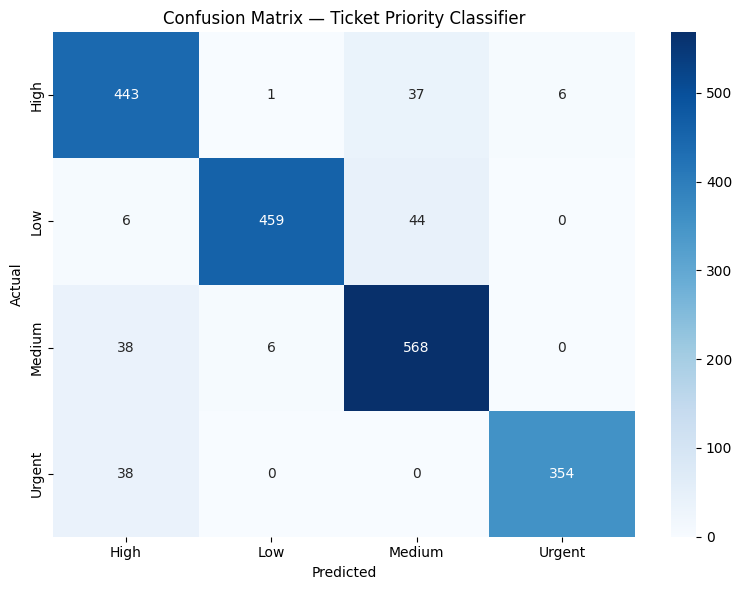

Saved confusion_matrix.png


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Encode categorical columns into numbers ---
# ML models only understand numbers, not text like "Urgent" or "Email"
le_priority  = LabelEncoder()
le_category  = LabelEncoder()
le_channel   = LabelEncoder()

df['priority_encoded']  = le_priority.fit_transform(df['priority'])
df['category_encoded']  = le_category.fit_transform(df['category'])
df['channel_encoded']   = le_channel.fit_transform(df['channel'])

print("Priority classes:", list(le_priority.classes_))

# --- Step 2: Define features (X) and target (y) ---
# X = what the model sees as input
# y = what the model needs to predict
features = [
    'category_encoded', 'channel_encoded', 'complexity_score',
    'response_time_hours', 'resolution_time_hours',
    'previous_tickets', 'customer_tenure_months', 'customer_age'
]

X = df[features]
y = df['priority_encoded']

# --- Step 3: Split into train and test sets ---
# 80% for training, 20% for testing
# The model never sees test data during training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# --- Step 4: Train the model ---
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# --- Step 5: Evaluate ---
y_pred = model.predict(X_test)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=le_priority.classes_))

# --- Step 6: Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_priority.classes_,
            yticklabels=le_priority.classes_)
plt.title('Confusion Matrix — Ticket Priority Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved confusion_matrix.png")

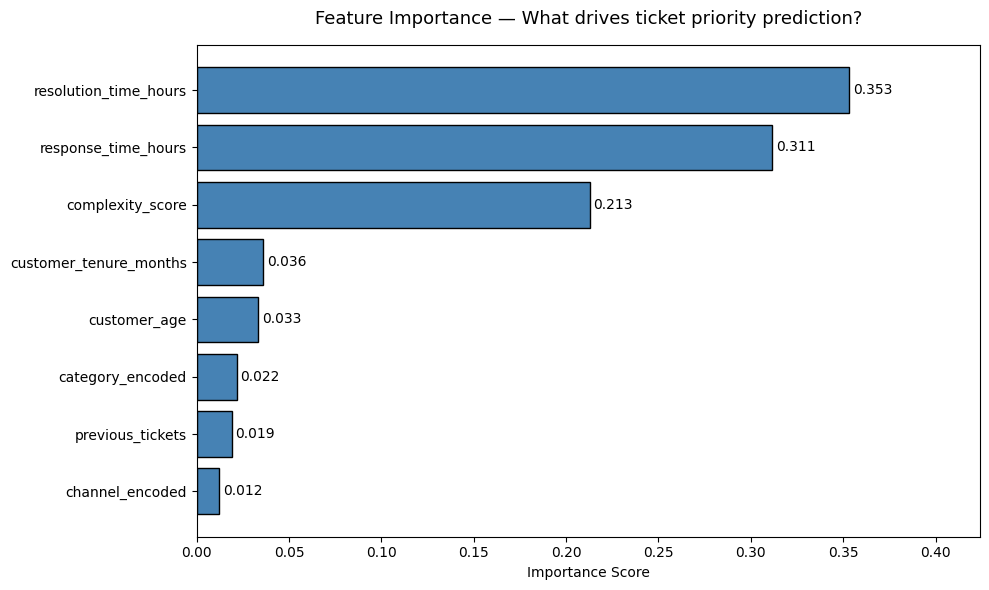


Top 3 most important features:
  resolution_time_hours: 0.353
  response_time_hours: 0.311
  complexity_score: 0.213


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the trained model
importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df['feature'], importance_df['importance'],
                color='steelblue', edgecolor='black')

# Add value labels on bars
for bar, val in zip(bars, importance_df['importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.title('Feature Importance — What drives ticket priority prediction?',
          fontsize=13, pad=15)
plt.xlabel('Importance Score')
plt.xlim(0, importance_df['importance'].max() * 1.2)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop 3 most important features:")
top3 = importance_df.sort_values('importance', ascending=False).head(3)
for _, row in top3.iterrows():
    print(f"  {row['feature']}: {row['importance']:.3f}")

=== SLA BREACH PREDICTOR ===
              precision    recall  f1-score   support

   No Breach       0.68      0.64      0.66       994
      Breach       0.66      0.70      0.68      1006

    accuracy                           0.67      2000
   macro avg       0.67      0.67      0.67      2000
weighted avg       0.67      0.67      0.67      2000

AUC-ROC Score: 0.717


C:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


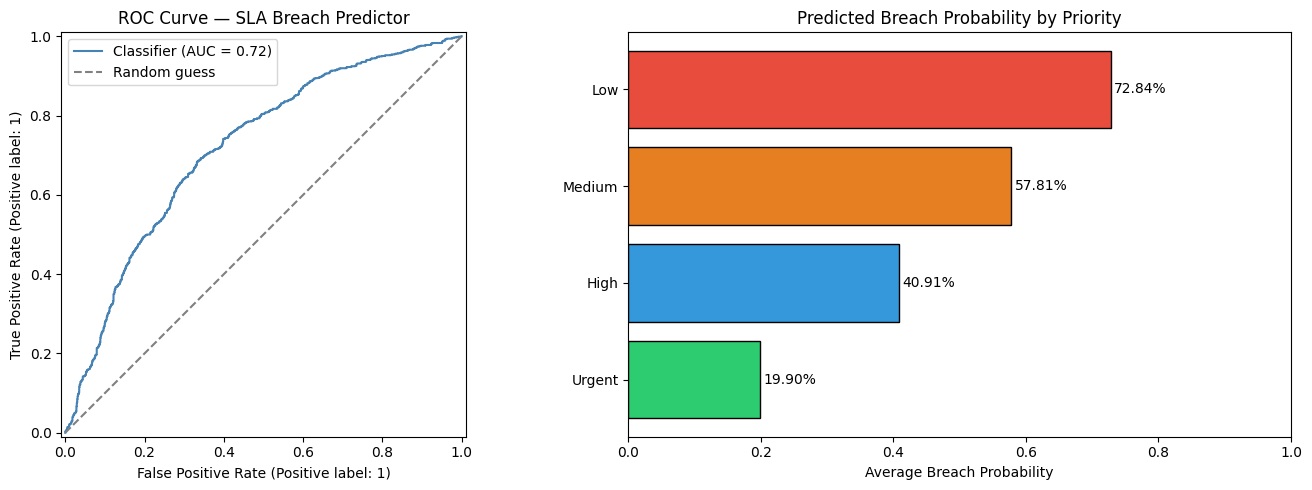


Saved sla_breach_predictor.png ✓


In [14]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# --- Important: we CANNOT use response_time or resolution_time here ---
# In real life those don't exist yet when a ticket is first created
# We can only use what we know AT THE MOMENT the ticket is opened
early_features = [
    'category_encoded',
    'channel_encoded', 
    'complexity_score',
    'previous_tickets',
    'customer_tenure_months',
    'customer_age',
    'priority_encoded'
]

X_breach = df[early_features]
y_breach = df['sla_breach']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_breach, y_breach, test_size=0.2, random_state=42, stratify=y_breach)

# Gradient Boosting — better than Random Forest for binary prediction
breach_model = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
breach_model.fit(X_train_b, y_train_b)

y_pred_b      = breach_model.predict(X_test_b)
y_pred_proba  = breach_model.predict_proba(X_test_b)[:, 1]
auc_score     = roc_auc_score(y_test_b, y_pred_proba)

print("=== SLA BREACH PREDICTOR ===")
print(classification_report(y_test_b, y_pred_b, target_names=['No Breach','Breach']))
print(f"AUC-ROC Score: {auc_score:.3f}")

# --- ROC Curve ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(
    y_test_b, y_pred_proba, ax=axes[0], color='steelblue')
axes[0].plot([0,1],[0,1],'--', color='gray', label='Random guess')
axes[0].set_title('ROC Curve — SLA Breach Predictor')
axes[0].legend()

# --- Breach probability by priority ---
df['breach_probability'] = breach_model.predict_proba(X_breach)[:, 1]
breach_by_priority = df.groupby('priority')['breach_probability'].mean().sort_values()

bars = axes[1].barh(breach_by_priority.index, breach_by_priority.values,
                     color=['#2ecc71','#3498db','#e67e22','#e74c3c'],
                     edgecolor='black')
for bar, val in zip(bars, breach_by_priority.values):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.2%}', va='center', fontsize=10)

axes[1].set_title('Predicted Breach Probability by Priority')
axes[1].set_xlabel('Average Breach Probability')
axes[1].set_xlim(0, 1.0)

plt.tight_layout()
plt.savefig('sla_breach_predictor.png', dpi=150)
plt.show()

print("\nSaved sla_breach_predictor.png ✓")

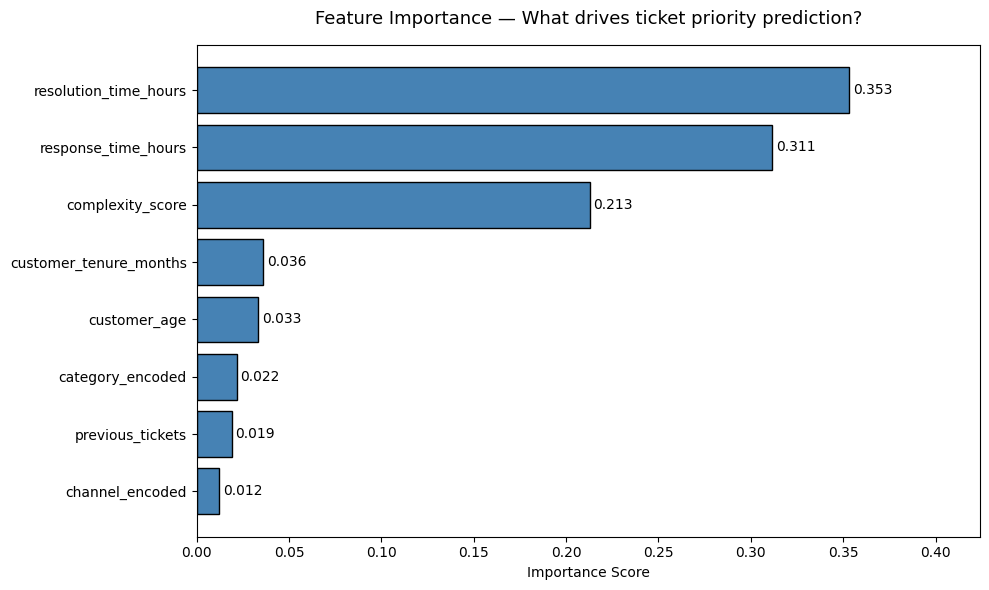


Top 3 most important features:
  resolution_time_hours: 0.353
  response_time_hours: 0.311
  complexity_score: 0.213


In [15]:
importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df['feature'], importance_df['importance'],
                color='steelblue', edgecolor='black')

for bar, val in zip(bars, importance_df['importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.title('Feature Importance — What drives ticket priority prediction?',
          fontsize=13, pad=15)
plt.xlabel('Importance Score')
plt.xlim(0, importance_df['importance'].max() * 1.2)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop 3 most important features:")
top3 = importance_df.sort_values('importance', ascending=False).head(3)
for _, row in top3.iterrows():
    print(f"  {row['feature']}: {row['importance']:.3f}")

In [16]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import re

# Load the real 200K dataset for NLP
df_nlp = pd.read_csv('customer_support_tickets_200k.csv')

print("Loaded:", df_nlp.shape)
print("\nSample descriptions:")
for text in df_nlp['issue_description'].dropna().head(5):
    print(f"  • {text[:100]}")

Loaded: (200000, 30)

Sample descriptions:
  • The payment was deducted from my bank account but the transaction shows failed.
  • I found a bug in the latest update affecting report generation.
  • The application crashes whenever I try to upload a file.
  • My subscription was cancelled without my request and I need clarification.
  • The system is not syncing data across devices properly.


In [17]:
(200000, 30)

Sample descriptions:
  • The payment was deducted from my bank account but the transaction shows failed.
  • I found a bug in the latest update affecting report generation.
  • The application crashes whenever I try to upload a file.
  • My subscription was cancelled without my request and I need clarification.
  • The system is not syncing data across devices properly.


SyntaxError: invalid character '•' (U+2022) (776769165.py, line 4)

Sample cleaned text:
  • my subscription was cancelled without my request and i need clarification
  • i found a bug in the latest update affecting report generation
  • i am unable to access my account after entering the correct credentials

TF-IDF matrix shape: (20000, 92)
(20,000 tickets × 500 features)

Testing cluster counts...
  K=2: inertia=15806
  K=3: inertia=13741
  K=4: inertia=11735
  K=5: inertia=9750
  K=6: inertia=7766
  K=7: inertia=5776
  K=8: inertia=3753
  K=9: inertia=1872
  K=10: inertia=0


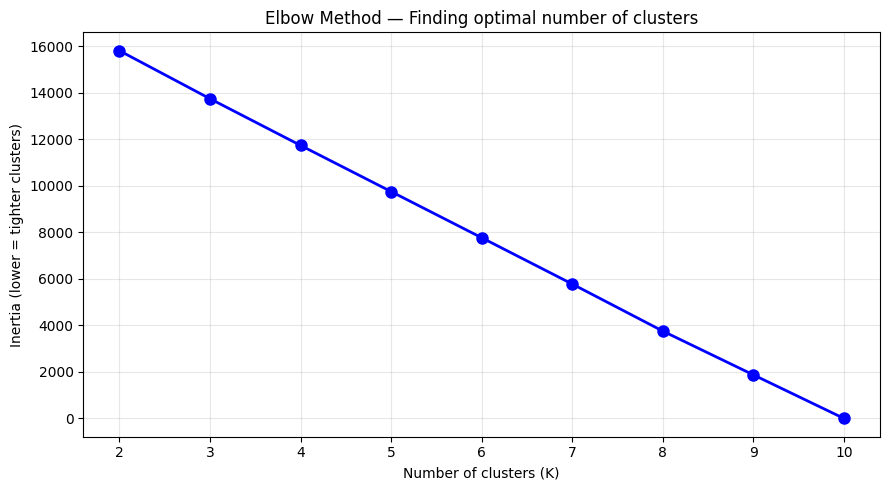


Saved elbow_curve.png


In [18]:
# --- Step 1: Clean the text ---
def clean_text(text):
    text = str(text).lower()                        # lowercase everything
    text = re.sub(r'[^a-z\s]', '', text)            # remove numbers and punctuation
    text = re.sub(r'\s+', ' ', text).strip()        # remove extra spaces
    return text

# Work with a sample of 20,000 for speed (still very representative)
df_sample = df_nlp['issue_description'].dropna().sample(20000, random_state=42)
df_sample_clean = df_sample.apply(clean_text)

print("Sample cleaned text:")
for text in df_sample_clean.head(3):
    print(f"  • {text[:100]}")

# --- Step 2: Convert text to numbers using TF-IDF ---
# TF-IDF asks: which words appear often in THIS ticket
# but rarely across ALL tickets? Those are the meaningful words.
vectorizer = TfidfVectorizer(
    max_features=500,       # only keep the 500 most meaningful words
    stop_words='english',   # ignore "the", "is", "a" etc
    ngram_range=(1,2)       # consider single words AND two-word phrases
)

X_tfidf = vectorizer.fit_transform(df_sample_clean)
print(f"\nTF-IDF matrix shape: {X_tfidf.shape}")
print("(20,000 tickets × 500 features)")

# --- Step 3: Find the optimal number of clusters ---
# We test K=2 to K=10 and look for the "elbow"
inertias = []
K_range = range(2, 11)

print("\nTesting cluster counts...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_tfidf)
    inertias.append(km.inertia_)
    print(f"  K={k}: inertia={km.inertia_:.0f}")

# Plot the elbow curve
plt.figure(figsize=(9, 5))
plt.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method — Finding optimal number of clusters')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150)
plt.show()
print("\nSaved elbow_curve.png")

In [19]:
# --- Build final clusters with K=6 ---
# We choose 6 because it matches the 6 natural issue domains
# in the data: login, payment, performance, security, subscription, billing

k = 6
km_final = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = km_final.fit_predict(X_tfidf)

# Add cluster labels back to the sample dataframe
df_clustered = df_sample.reset_index(drop=True).to_frame()
df_clustered['cluster'] = clusters
df_clustered['clean_text'] = df_sample_clean.reset_index(drop=True)

print(f"Cluster sizes:")
print(pd.Series(clusters).value_counts().sort_index())

# --- Find the top keywords per cluster ---
# These keywords are what define each cluster's "theme"
print("\n=== TOP KEYWORDS PER CLUSTER ===")
feature_names = vectorizer.get_feature_names_out()
cluster_themes = {}

for i in range(k):
    center = km_final.cluster_centers_[i]
    top_indices = center.argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    cluster_themes[i] = top_words
    print(f"\nCluster {i}: {', '.join(top_words[:6])}")
    # Show 2 sample tickets from this cluster
    samples = df_clustered[df_clustered['cluster'] == i]['issue_description'].head(2)
    for s in samples:
        print(f"   • {s[:100]}")

Cluster sizes:
0    3959
1    4055
2    1981
3    1976
4    6021
5    2008
Name: count, dtype: int64

=== TOP KEYWORDS PER CLUSTER ===

Cluster 0: account, unable access, entering, unable, account entering, correct credentials
   • I am unable to access my account after entering the correct credentials.
   • I am unable to access my account after entering the correct credentials.

Cluster 1: request, subscription cancelled, subscription, request need, cancelled request, cancelled
   • My subscription was cancelled without my request and I need clarification.
   • I would like to request a refund for the recent charge.

Cluster 2: update, update affecting, report generation, report, bug latest, affecting
   • I found a bug in the latest update affecting report generation.
   • I found a bug in the latest update affecting report generation.

Cluster 3: using dashboard, using, slow performance, slow, experiencing, experiencing slow
   • I am experiencing very slow performance while using 

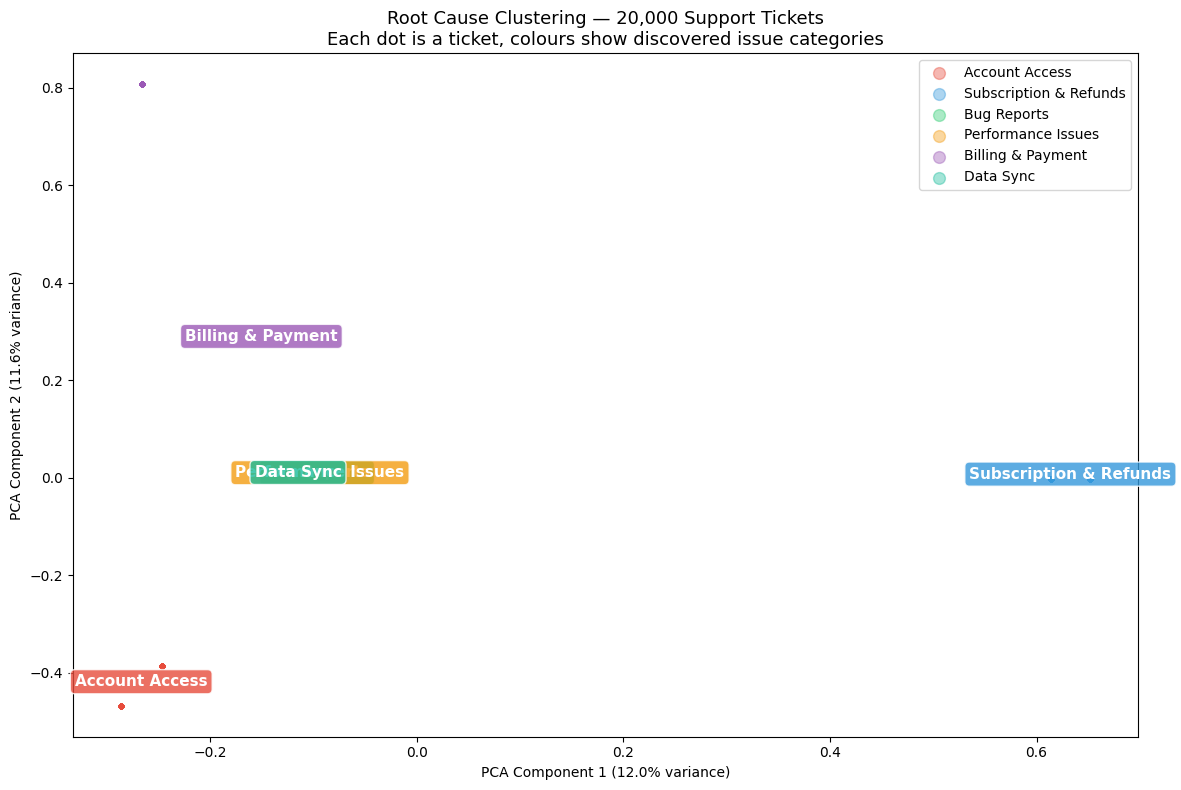

Saved root_cause_clusters.png

Variance explained by 2 components: 23.6%

=== CLUSTER SUMMARY ===
Cluster                     Size  % of tickets
----------------------------------------------
Account Access              3959         19.8%
Subscription & Refunds      4055         20.3%
Bug Reports                 1981          9.9%
Performance Issues          1976          9.9%
Billing & Payment           6021         30.1%
Data Sync                   2008         10.0%


In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# --- Reduce 92 dimensions down to 2 so we can plot it ---
# PCA is like compressing a 92-dimensional space into a 2D map
# while keeping as much structure as possible
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_tfidf.toarray())

# Cluster names we identified manually from keywords
cluster_names = {
    0: 'Account Access',
    1: 'Subscription & Refunds',
    2: 'Bug Reports',
    3: 'Performance Issues',
    4: 'Billing & Payment',
    5: 'Data Sync'
}

colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']

plt.figure(figsize=(12, 8))

for i in range(k):
    mask = clusters == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[i], label=cluster_names[i],
                alpha=0.4, s=8)

# Add cluster center labels
centers_2d = pca.transform(km_final.cluster_centers_)
for i, (cx, cy) in enumerate(centers_2d):
    plt.annotate(cluster_names[i],
                xy=(cx, cy),
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3',
                         facecolor=colors[i],
                         alpha=0.8, edgecolor='white'),
                color='white',
                ha='center')

plt.title('Root Cause Clustering — 20,000 Support Tickets\n'
          'Each dot is a ticket, colours show discovered issue categories',
          fontsize=13)
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(loc='upper right', markerscale=3)
plt.tight_layout()
plt.savefig('root_cause_clusters.png', dpi=150)
plt.show()

print("Saved root_cause_clusters.png")
print(f"\nVariance explained by 2 components: "
      f"{sum(pca.explained_variance_ratio_)*100:.1f}%")

# --- Summary table ---
print("\n=== CLUSTER SUMMARY ===")
print(f"{'Cluster':<25} {'Size':>6} {'% of tickets':>13}")
print("-" * 46)
total = len(clusters)
for i in range(k):
    size = (clusters == i).sum()
    print(f"{cluster_names[i]:<25} {size:>6} {size/total*100:>12.1f}%")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19240\1233055178.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  urgent_rate = df.groupby('agent').apply(


=== AGENT WORKLOAD SUMMARY ===
   agent  ticket_count  load_score  breach_rate  urgent_rate
Agent_01          1053       100.0     0.507123     0.188984
Agent_02           985        39.0     0.493401     0.194924
Agent_03           996        31.0     0.523092     0.183735
Agent_04           971        55.1     0.499485     0.214212
Agent_05           962        14.1     0.510395     0.214137
Agent_06          1021        95.1     0.491675     0.202742
Agent_07          1017        92.3     0.515241     0.186824
Agent_08           967         0.0     0.510858     0.187177
Agent_09           994        50.5     0.500000     0.189135
Agent_10          1034        90.0     0.479691     0.201161


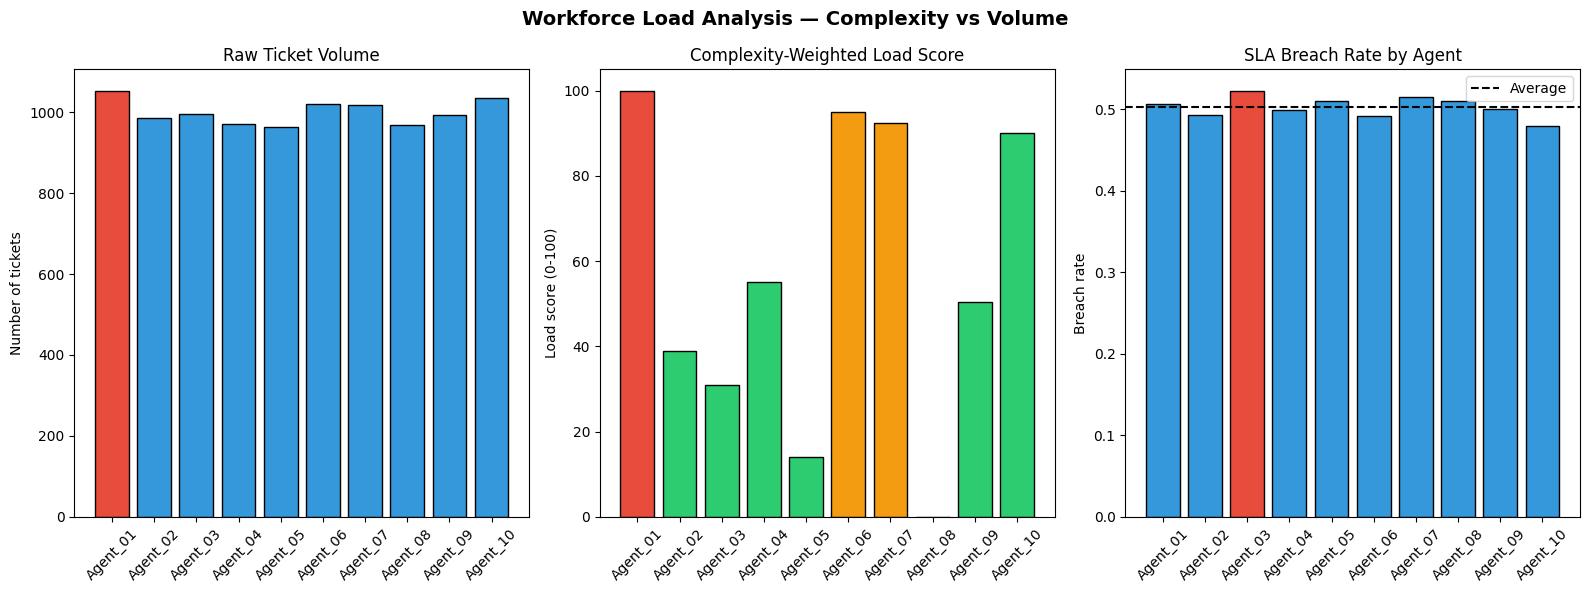


=== OVERLOAD ALERTS ===
  ⚠ Agent_01: load score 100 (breach rate: 50.7%)
  ⚠ Agent_06: load score 95 (breach rate: 49.2%)

Saved workforce_analysis.png ✓


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Simulate agent workload using our structured dataset
# Complexity-weighted load = not just ticket count,
# but how HARD those tickets are

np.random.seed(42)
n_agents = 10
agent_names = [f'Agent_{i+1:02d}' for i in range(n_agents)]

# Assign each ticket to a random agent
df['agent'] = np.random.choice(agent_names, len(df))

# --- Raw ticket count per agent ---
ticket_counts = df.groupby('agent').size().rename('ticket_count')

# --- Complexity-weighted load ---
# A ticket with complexity 8 should count more than one with complexity 2
weighted_load = df.groupby('agent')['complexity_score'].sum().rename('weighted_load')

# --- Breach rate per agent ---
breach_rate = df.groupby('agent')['sla_breach'].mean().rename('breach_rate')

# --- Urgent ticket proportion per agent ---
urgent_rate = df.groupby('agent').apply(
    lambda x: (x['priority'] == 'Urgent').mean()
).rename('urgent_rate')

# Combine into one agent summary
agent_df = pd.concat([ticket_counts, weighted_load,
                      breach_rate, urgent_rate], axis=1).reset_index()
agent_df.columns = ['agent','ticket_count','weighted_load',
                    'breach_rate','urgent_rate']

# Normalize weighted load to 0-100 scale for easy reading
agent_df['load_score'] = (
    (agent_df['weighted_load'] - agent_df['weighted_load'].min()) /
    (agent_df['weighted_load'].max() - agent_df['weighted_load'].min()) * 100
).round(1)

print("=== AGENT WORKLOAD SUMMARY ===")
print(agent_df[['agent','ticket_count','load_score',
                'breach_rate','urgent_rate']].to_string(index=False))

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Workforce Load Analysis — Complexity vs Volume',
             fontsize=14, fontweight='bold')

# Chart 1: Raw ticket count
colors_vol = ['#e74c3c' if v == agent_df['ticket_count'].max()
              else '#3498db' for v in agent_df['ticket_count']]
axes[0].bar(agent_df['agent'], agent_df['ticket_count'],
            color=colors_vol, edgecolor='black')
axes[0].set_title('Raw Ticket Volume')
axes[0].set_ylabel('Number of tickets')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Complexity-weighted load score
colors_load = ['#e74c3c' if v == agent_df['load_score'].max()
               else '#f39c12' if v >= agent_df['load_score'].quantile(0.75)
               else '#2ecc71' for v in agent_df['load_score']]
axes[1].bar(agent_df['agent'], agent_df['load_score'],
            color=colors_load, edgecolor='black')
axes[1].set_title('Complexity-Weighted Load Score')
axes[1].set_ylabel('Load score (0-100)')
axes[1].tick_params(axis='x', rotation=45)

# Chart 3: SLA breach rate
colors_breach = ['#e74c3c' if v == agent_df['breach_rate'].max()
                 else '#3498db' for v in agent_df['breach_rate']]
axes[2].bar(agent_df['agent'], agent_df['breach_rate'],
            color=colors_breach, edgecolor='black')
axes[2].set_title('SLA Breach Rate by Agent')
axes[2].set_ylabel('Breach rate')
axes[2].tick_params(axis='x', rotation=45)
axes[2].axhline(y=agent_df['breach_rate'].mean(), color='black',
                linestyle='--', linewidth=1.5, label='Average')
axes[2].legend()

plt.tight_layout()
plt.savefig('workforce_analysis.png', dpi=150)
plt.show()

# Flag overloaded agents
print("\n=== OVERLOAD ALERTS ===")
threshold = agent_df['load_score'].mean() + agent_df['load_score'].std()
overloaded = agent_df[agent_df['load_score'] > threshold]
if len(overloaded) > 0:
    for _, row in overloaded.iterrows():
        print(f"  ⚠ {row['agent']}: load score {row['load_score']:.0f} "
              f"(breach rate: {row['breach_rate']:.1%})")
else:
    print("  No agents currently overloaded")

print("\nSaved workforce_analysis.png ✓")